In [1]:
import json
import re
import requests

import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, CrossEncoder

chunk_df = pd.read_parquet("all_corpus_final_chunks.parquet")
embeddings = np.load("all_corpus_embeddings.npy")
index = faiss.read_index("all_corpus_faiss.index")

embedding_model_name = "BAAI/bge-small-en-v1.5"
embedding_model = SentenceTransformer(embedding_model_name)

reranker_model_name = "BAAI/bge-reranker-base"
reranker = CrossEncoder(reranker_model_name)

valid_tickers = sorted(chunk_df["ticker"].unique())

chunk_df.shape, embeddings.shape, index.ntotal, len(valid_tickers)

/home/wagyu0923/miniconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1837.83it/s]


((301184, 6), (301184, 384), 301184, 497)

In [2]:
from pathlib import Path
from html import unescape
import re

corpus_dir = Path("../10k")

entity_name_pattern = re.compile(
    r'<ix:nonNumeric\b(?=[^>]*\bname=["\']dei:EntityRegistrantName["\'])[^>]*>(.*?)</ix:nonNumeric>|'
    r'<ix:nonnumeric\b(?=[^>]*\bname=["\']dei:EntityRegistrantName["\'])[^>]*>(.*?)</ix:nonnumeric>',
    re.IGNORECASE | re.DOTALL,
)

tag_pattern = re.compile(r"<[^>]+>")
space_pattern = re.compile(r"\s+")


def clean_html_text(text):
    text = tag_pattern.sub(" ", text)
    text = unescape(text)
    text = space_pattern.sub(" ", text).strip()
    return text


ticker_to_company = {}

for html_path in sorted(corpus_dir.glob("*.html")):
    ticker = html_path.stem
    html = html_path.read_text(encoding="utf-8", errors="ignore")
    match = entity_name_pattern.search(html)

    if match is None:
        continue

    raw_company_name = next(
        group for group in match.groups()
        if group is not None
    )

    ticker_to_company[ticker] = clean_html_text(raw_company_name)

len(ticker_to_company), list(ticker_to_company.items())[:5]

(497,
 [('A', 'Agilent Technologies, Inc.'),
  ('AAL', 'American Airlines Group Inc.'),
  ('AAPL', 'Apple Inc.'),
  ('ABBV', 'AbbVie Inc.'),
  ('ABNB', 'Airbnb, Inc.')])

In [3]:
entity_df = pd.DataFrame(
    [
        {"ticker": ticker, "company": company}
        for ticker, company in ticker_to_company.items()
    ]
)

entity_texts = (
    "Ticker: " + entity_df["ticker"].astype(str)
    + "\nCompany: "+ entity_df["company"].astype(str)
).tolist()

entity_embeddings = embedding_model.encode(
    entity_texts,
    normalize_embeddings=True,
).astype("float32")

def ticker_variants(ticker):
    return {
        ticker,
        ticker.replace("-","."),
        ticker.replace("-",""),
    }

def find_explicit_tickers(query):
    found = []

    for ticker in ticker_to_company:
        compact_ticker = ticker.replace("-","").replace(".","")

        if len(compact_ticker) < 3:
            continue

        for variant in ticker_variants(ticker):
            pattern = (
            r"(?<![A-Za-z0-9])"
            + re.escape(variant)
            + r"(?![A-Za-z0-9])"
            )

            if re.search(pattern, query):
                found.append(ticker)
                break
    
    return found


def build_ticker_candidates(query, ticker_to_company, top_k=10):
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True,
    ).astype("float32")[0]

    scores = entity_embeddings@query_embedding
    
    top_indices = np.argsort(scores)[::-1][:top_k]

    tickers = []

    tickers.extend(find_explicit_tickers(query))

    for idx in top_indices:
        tickers.append(entity_df.iloc[idx]["ticker"])

    tickers = list(dict.fromkeys(tickers))

    candidates = [
        {
            "ticker" : ticker,
            "company" : ticker_to_company[ticker],
        }
        for ticker in tickers
    ]

    return candidates

In [4]:
OLLAMA_MODEL = "qwen3.5:9b"


def resolve_tickers(query, candidates):
    candidate_tickers = [candidate["ticker"] for candidate in candidates]

    ticker_resolution_schema = {
        "type": "object",
        "properties": {
            "tickers": {
                "type": "array",
                "items": {
                    "type": "string",
                    "enum": candidate_tickers,
                },
            },
            "confidence": {
                "type": "string",
                "enum": ["high", "medium", "low"],
            },
        },
        "required": ["tickers", "confidence"],
        "additionalProperties": False,
    }

    candidate_text = "\n".join(
        f"- {candidate['ticker']}: {candidate['company']}"
        for candidate in candidates
    )

    prompt = f"""
You are an entity linker for financial QA.

Your task is to choose which candidate company or companies the question is actually asking about.

Candidates:
{candidate_text}

Return raw JSON only in this format:
{{"tickers": ["AAPL"], "confidence": "high"}}

Rules:
- Use only tickers from the candidate list.
- Select the company or companies that the question is actually asking about.
- If multiple candidates are truly required for comparison or relationship analysis, return multiple tickers.
- Ignore stock exchanges, accounting terms, financial metrics, rating agencies, products, and generic market words unless they are clearly the target company.
- If none of the candidates is clearly the target company, return an empty ticker list and confidence "low".
- Do not explain your answer.
- Do not use markdown code fences.

Question:
{query}
""".strip()

    response = requests.post(
        "http://localhost:11434/api/chat",
        json={
            "model": OLLAMA_MODEL,
            "messages": [{"role": "user", "content": prompt}],
            "stream": False,
            "format": ticker_resolution_schema,
            "think": False,
            "options": {"temperature": 0},
        },
        timeout=60,
    )

    response.raise_for_status()

    parsed = json.loads(response.json()["message"]["content"])

    tickers = [
        ticker
        for ticker in parsed["tickers"]
        if ticker in candidate_tickers
    ]

    confidence = parsed["confidence"]

    if not tickers:
        confidence = "low"

    return {
        "tickers": tickers,
        "confidence": confidence,
    }

In [5]:
def retrieve_candidates(query, tickers=None , top_k=50 ,fetch_k=200):
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True,
    ).astype("float32")

    if tickers is None:
        scores, indices = index.search(query_embedding, fetch_k)

        candidates = chunk_df.iloc[indices[0]].copy()
        candidates["retriever_score"] = scores[0]

        return candidates[
            [
                "retriever_score",
                "chunk_id",
                "ticker",
                "chunk_type",
                "section_title",
                "text"
            ]
        ].head(top_k)

    ticker_mask = chunk_df["ticker"].isin(tickers)
    ticker_chunk_df = chunk_df[ticker_mask].copy()
    ticker_embeddings = embeddings[ticker_mask.to_numpy()]
    scores = ticker_embeddings @ query_embedding[0]
    top_indices = np.argsort(scores)[::-1][:top_k]
    candidates = ticker_chunk_df.iloc[top_indices].copy()

    candidates["retriever_score"] = scores[top_indices]

    return candidates[
    [
        "retriever_score",
        "chunk_id",
        "ticker",
        "chunk_type",
        "section_title",
        "text",
    ]
]


In [6]:
def rerank_candidates(query, candidates, top_k=5):
    company_names = candidates["ticker"].map(ticker_to_company).fillna(candidates["ticker"])
    reranker_texts = (
        "Company: " + company_names.astype(str)+
        "\nTicker: " + candidates["ticker"].astype(str)
        + "\n\n" + candidates["text"].astype(str) 
    ).tolist()

    pairs = [
        [query, text]
        for text in reranker_texts
    ]

    reranker_scores = reranker.predict(pairs)

    reranked = candidates.copy()
    reranked["reranker_score"] = reranker_scores

    reranked = reranked.sort_values(
        "reranker_score",
        ascending=False,
    )

    return reranked[
        [
         "reranker_score",
         "retriever_score",
         "chunk_id",
         "ticker",
         "chunk_type",
         "section_title",
         "text"
        ]
    ].head(top_k)

In [7]:
qa_df = pd.read_parquet(
    "hf://datasets/Linq-AI-Research/FinDER/data/train-00000-of-00001.parquet"
)

qa_df.shape, qa_df.columns

((5703, 7),
 Index(['_id', 'text', 'reasoning', 'category', 'references', 'answer', 'type'], dtype='object'))

In [8]:
qa_df["has_reference"] = qa_df["references"].apply(
    lambda references: any(
        str(reference).strip() != "None."
        for reference in references
    )
)

qa_df["has_reference"].value_counts()

has_reference
True     5656
False      47
Name: count, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

train_df, remaining_df = train_test_split(
    qa_df,
    test_size=0.2,
    random_state=42,
    stratify=qa_df['category']
    
)

validation_df, test_df = train_test_split(
    remaining_df,
    test_size=0.5,
    random_state=42,
    stratify=remaining_df["category"]
)

train_df = train_df.copy()
validation_df = validation_df.copy()
test_df = test_df.copy()

len(train_df), len(validation_df), len(test_df)

(4562, 570, 571)

In [10]:
def run_retrieval_methods(query):
    basic_results = retrieve_candidates(
        query,
        tickers=None,
        top_k=10,
        fetch_k=10
    )

    ticker_candidates = build_ticker_candidates(
        query,
        ticker_to_company,
    )

    resolved = resolve_tickers(
        query,
        ticker_candidates
    )

    if not resolved["tickers"]:
        return {
            "resolved" : resolved,
            "basic" : basic_results,
            "entity_aware" : pd.DataFrame(),
            "entity_aware_reranked" : pd.DataFrame()
        }
    
    entity_candidates = retrieve_candidates(
        query,
        tickers=resolved["tickers"],
        top_k=50
    )

    reranked_results = rerank_candidates(
        query,
        entity_candidates,
        top_k=5
    )

    return {
        "resolved": resolved,
        "basic": basic_results,
        "entity_aware": entity_candidates.head(10),
        "entity_aware_reranked": reranked_results,
    }

In [11]:
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm


validation_retrieval_path = Path(
    "validation_retrieval_results.parquet"
)

validation_failures = []

if validation_retrieval_path.exists():
    validation_retrieval_df = pd.read_parquet(
        validation_retrieval_path
    )

else:
    validation_result_rows = []

    for row_index, row in tqdm(
        validation_df.iterrows(),
        total=len(validation_df),
    ):
        try:
            outputs = run_retrieval_methods(
                row["text"]
            )

            for method in [
                "basic",
                "entity_aware",
                "entity_aware_reranked",
            ]:
                method_results = outputs[method]

                for rank, result in enumerate(
                    method_results.itertuples(
                        index=False
                    ),
                    start=1,
                ):
                    validation_result_rows.append({
                        "question_id": row["_id"],
                        "question_index": row_index,
                        "query": row["text"],
                        "method": method,
                        "rank": rank,
                        "resolved_tickers": (
                            outputs["resolved"]["tickers"]
                        ),
                        "confidence": (
                            outputs["resolved"]["confidence"]
                        ),
                        "chunk_id": result.chunk_id,
                        "retriever_score": (
                            result.retriever_score
                        ),
                        "reranker_score": getattr(
                            result,
                            "reranker_score",
                            np.nan,
                        ),
                        "text": result.text,
                    })

        except Exception as error:
            validation_failures.append({
                "question_id": row["_id"],
                "question_index": row_index,
                "error": repr(error),
            })

    validation_retrieval_df = pd.DataFrame(
        validation_result_rows
    )

    validation_retrieval_df.to_parquet(
        validation_retrieval_path,
        index=False,
    )


(
    validation_retrieval_df.shape,
    len(validation_failures),
    validation_retrieval_df[
        "method"
    ].value_counts(),
)

((14025, 11),
 0,
 method
 basic                    5700
 entity_aware             5550
 entity_aware_reranked    2775
 Name: count, dtype: int64)

In [12]:
validation_contexts_df = (
    validation_retrieval_df
    .sort_values([
        "question_id",
        "method",
        "rank",
    ])
    .groupby(
        ["question_id","method"],
        as_index=False,
    ).
    agg(
        retrieved_contexts=("text",list)
    )
)

(
    validation_contexts_df.shape,
    validation_contexts_df["method"].value_counts(),
)

((1680, 3),
 method
 basic                    570
 entity_aware             555
 entity_aware_reranked    555
 Name: count, dtype: int64)

In [13]:
retrieval_questions_df = validation_df[
    validation_df["has_reference"]
][
    ["_id","text","references","category"]
].copy()

retrieval_questions_df.shape

(569, 4)

In [14]:
retrieval_questions_df = retrieval_questions_df.rename(
    columns={
        "_id": "question_id",
        "text": "query",
    }
)

retrieval_questions_df.columns

Index(['question_id', 'query', 'references', 'category'], dtype='object')

In [15]:
retrieval_questions_df["reference"] = (
    retrieval_questions_df["references"]
    .str.join("\n\n")
)

retrieval_questions_df[
    ["references", "reference"]
].head(1)

,references,reference
4673,"[We face competition from other railroads, mot...","We face competition from other railroads, moto..."


In [16]:
methods_df = pd.DataFrame({
    "method" : [
        "basic",
        "entity_aware",
        "entity_aware_reranked"
    ]
})

retrieval_eval_df = (
    retrieval_questions_df
    .drop(columns="references")
    .merge(
        methods_df,
        how="cross",
    )
)

(
    retrieval_eval_df.shape,
    retrieval_eval_df["method"].value_counts(),
)

((1707, 5),
 method
 basic                    569
 entity_aware             569
 entity_aware_reranked    569
 Name: count, dtype: int64)

In [17]:
retrieval_eval_df = retrieval_eval_df.merge(
    validation_contexts_df,
    on=[
        "question_id",
        "method"
    ],
    how="left",
)

(
    retrieval_eval_df.shape,
    retrieval_eval_df.groupby("method")[
        "retrieved_contexts"
    ].apply(
        lambda contexts: contexts.isna().sum()
    ),
)

((1707, 6),
 method
 basic                     0
 entity_aware             15
 entity_aware_reranked    15
 Name: retrieved_contexts, dtype: int64)

In [18]:
retrieval_eval_df["retrieved_contexts"] = (
    retrieval_eval_df["retrieved_contexts"].apply(
        lambda contexts: (
            contexts
            if isinstance(contexts, list)
            else []
        )
    )
)

(
    retrieval_eval_df["retrieved_contexts"].isna().sum(),
    retrieval_eval_df.groupby("method")[
        "retrieved_contexts"
    ].apply(
        lambda contexts: contexts.map(len).eq(0).sum()
    ),
)

(np.int64(0),
 method
 basic                     0
 entity_aware             15
 entity_aware_reranked    15
 Name: retrieved_contexts, dtype: int64)

In [19]:
from importlib.metadata import distribution
from pathlib import Path

ragas_base_path = Path(
    distribution("ragas").locate_file("ragas/llms/base.py")
)

source = ragas_base_path.read_text(encoding="utf-8")

old_import = (
    "from langchain_community.chat_models.vertexai "
    "import ChatVertexAI"
)
new_import = (
    "from langchain_google_vertexai "
    "import ChatVertexAI"
)

if old_import in source:
    source = source.replace(old_import, new_import)
    ragas_base_path.write_text(source, encoding="utf-8")

print(ragas_base_path)

/home/wagyu0923/miniconda3/envs/nlp/lib/python3.11/site-packages/ragas/llms/base.py


In [20]:
from google.auth import default
from google.auth.transport.requests import Request
from openai import AsyncOpenAI
from ragas.llms import llm_factory
from ragas.metrics.collections import ContextRecall

PROJECT_ID = "project-42b5bbf4-64ff-45de-984"
LOCATION = "global"

credentials, _ = default(
    scopes=[
        "https://www.googleapis.com/auth/cloud-platform"
    ]
)
credentials.refresh(Request())

agent_platform_client = AsyncOpenAI(
    base_url=(
        "https://aiplatform.googleapis.com/v1/"
        f"projects/{PROJECT_ID}/locations/{LOCATION}/"
        "endpoints/openapi"
    ),
    api_key=credentials.token,
)

evaluator_llm = llm_factory(
    "google/gemini-3.1-flash-lite",
    client=agent_platform_client,
    temperature=0,
    max_tokens=8192,
    extra_body={
        "extra_body": {
            "google": {
                "thinking_config": {
                    "thinking_level": "minimal",
                },
            },
        },
    },
)

context_recall_scorer = ContextRecall(
    llm=evaluator_llm,
)

In [21]:
import asyncio
import random
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

checkpoint_path = Path(
    "validation_context_recall_flash_lite.parquet"
)

MAX_CONCURRENCY = 40
MAX_RETRIES = 5

semaphore = asyncio.Semaphore(MAX_CONCURRENCY)
credential_lock = asyncio.Lock()


async def refresh_credentials_if_needed():
    if credentials.valid:
        return

    async with credential_lock:
        if credentials.valid:
            return

        await asyncio.to_thread(
            credentials.refresh,
            Request(),
        )
        agent_platform_client.api_key = credentials.token


async def evaluate_context_recall_row(row):
    if not row.retrieved_contexts:
        return {
            "question_id": row.question_id,
            "method": row.method,
            "context_recall": 0.0,
            "error": None,
        }

    async with semaphore:
        for attempt in range(MAX_RETRIES):
            try:
                await refresh_credentials_if_needed()

                result = await context_recall_scorer.ascore(
                    user_input=row.query,
                    retrieved_contexts=row.retrieved_contexts,
                    reference=row.reference,
                )

                return {
                    "question_id": row.question_id,
                    "method": row.method,
                    "context_recall": result.value,
                    "error": None,
                }

            except Exception as error:
                if attempt == MAX_RETRIES - 1:
                    return {
                        "question_id": row.question_id,
                        "method": row.method,
                        "context_recall": None,
                        "error": repr(error),
                    }

                wait_seconds = min(
                    60,
                    2 ** attempt,
                ) + random.uniform(0, 1)

                await asyncio.sleep(wait_seconds)


if checkpoint_path.exists():
    existing_df = pd.read_parquet(checkpoint_path)
    existing_df = existing_df[
        existing_df["error"].isna()
    ].copy()

    context_recall_rows = existing_df.to_dict(
        orient="records"
    )
else:
    context_recall_rows = []


completed_keys = {
    (row["question_id"], row["method"])
    for row in context_recall_rows
}

pending_rows = [
    row
    for row in retrieval_eval_df.itertuples(index=False)
    if (row.question_id, row.method)
    not in completed_keys
]

tasks = [
    asyncio.create_task(
        evaluate_context_recall_row(row)
    )
    for row in pending_rows
]

for completed_count, task in enumerate(
    tqdm(
        asyncio.as_completed(tasks),
        total=len(tasks),
    ),
    start=1,
):
    result_row = await task
    context_recall_rows.append(result_row)

    if completed_count % 25 == 0:
        pd.DataFrame(context_recall_rows).to_parquet(
            checkpoint_path,
            index=False,
        )


context_recall_df = pd.DataFrame(
    context_recall_rows
).sort_values(
    ["question_id", "method"]
)

context_recall_df.to_parquet(
    checkpoint_path,
    index=False,
)

(
    context_recall_df.shape,
    context_recall_df["error"].notna().sum(),
    context_recall_df.groupby("method")[
        "context_recall"
    ].mean(),
)

0it [00:00, ?it/s]


((1707, 4),
 np.int64(0),
 method
 basic                    0.330699
 entity_aware             0.520911
 entity_aware_reranked    0.561241
 Name: context_recall, dtype: float64)

In [22]:
reranker_eval_df = retrieval_eval_df[
    retrieval_eval_df["method"].isin([
        "entity_aware",
        "entity_aware_reranked",
    ])
].copy()

reranker_eval_df["retrieved_contexts"] = (
    reranker_eval_df["retrieved_contexts"].apply(
        lambda contexts: contexts[:5]
    )
)

(
    reranker_eval_df.shape,
    reranker_eval_df.groupby("method")[
        "retrieved_contexts"
    ].apply(
        lambda contexts: contexts.map(len).describe()
    ),
)

((1138, 6),
 method                      
 entity_aware           count    569.000000
                        mean       4.868190
                        std        0.801752
                        min        0.000000
                        25%        5.000000
                        50%        5.000000
                        75%        5.000000
                        max        5.000000
 entity_aware_reranked  count    569.000000
                        mean       4.868190
                        std        0.801752
                        min        0.000000
                        25%        5.000000
                        50%        5.000000
                        75%        5.000000
                        max        5.000000
 Name: retrieved_contexts, dtype: float64)

In [23]:
from ragas.metrics.collections import ContextPrecision


context_precision_scorer = ContextPrecision(
    llm=evaluator_llm
)

precision_checkpoint_path = Path(
    "validation_context_precision_flash_lite.parquet"
)


async def evaluate_context_precision_row(row):
    if not row.retrieved_contexts:
        return {
            "question_id": row.question_id,
            "method": row.method,
            "context_precision": 0.0,
            "error": None,
        }

    async with semaphore:
        for attempt in range(MAX_RETRIES):
            try:
                await refresh_credentials_if_needed()

                result = await context_precision_scorer.ascore(
                    user_input=row.query,
                    reference=row.reference,
                    retrieved_contexts=(
                        row.retrieved_contexts
                    ),
                )

                return {
                    "question_id": row.question_id,
                    "method": row.method,
                    "context_precision": result.value,
                    "error": None,
                }

            except Exception as error:
                if attempt == MAX_RETRIES - 1:
                    return {
                        "question_id": row.question_id,
                        "method": row.method,
                        "context_precision": None,
                        "error": repr(error),
                    }

                wait_seconds = min(
                    60,
                    2 ** attempt,
                ) + random.uniform(0, 1)

                await asyncio.sleep(wait_seconds)


if precision_checkpoint_path.exists():
    existing_precision_df = pd.read_parquet(
        precision_checkpoint_path
    )

    existing_precision_df = existing_precision_df[
        existing_precision_df["error"].isna()
    ].copy()

    context_precision_rows = (
        existing_precision_df.to_dict(
            orient="records"
        )
    )
else:
    context_precision_rows = []


completed_precision_keys = {
    (row["question_id"], row["method"])
    for row in context_precision_rows
}

pending_precision_rows = [
    row
    for row in reranker_eval_df.itertuples(
        index=False
    )
    if (row.question_id, row.method)
    not in completed_precision_keys
]

precision_tasks = [
    asyncio.create_task(
        evaluate_context_precision_row(row)
    )
    for row in pending_precision_rows
]

for completed_count, task in enumerate(
    tqdm(
        asyncio.as_completed(precision_tasks),
        total=len(precision_tasks),
    ),
    start=1,
):
    result_row = await task
    context_precision_rows.append(result_row)

    if completed_count % 25 == 0:
        pd.DataFrame(
            context_precision_rows
        ).to_parquet(
            precision_checkpoint_path,
            index=False,
        )


context_precision_df = pd.DataFrame(
    context_precision_rows
).sort_values(
    [
        "question_id",
        "method",
    ]
)

context_precision_df.to_parquet(
    precision_checkpoint_path,
    index=False,
)

(
    context_precision_df.shape,
    context_precision_df[
        "error"
    ].notna().sum(),
    context_precision_df.groupby("method")[
        "context_precision"
    ].mean(),
)

100%|██████████| 1088/1088 [3:47:54<00:00, 12.57s/it] 


((1138, 4),
 np.int64(0),
 method
 entity_aware             0.366044
 entity_aware_reranked    0.407874
 Name: context_precision, dtype: float64)

In [24]:
async def run_checkpointed_evaluation(
    input_df,
    evaluate_row,
    checkpoint_path,
):
    checkpoint_path = Path(checkpoint_path)

    if checkpoint_path.exists():
        saved_df = pd.read_parquet(checkpoint_path)
        saved_df = saved_df[
            saved_df["error"].isna()
        ].copy()
        result_rows = saved_df.to_dict(orient="records")
    else:
        result_rows = []

    completed_keys = {
        (row["question_id"], row["method"])
        for row in result_rows
    }

    pending_rows = [
        row
        for row in input_df.itertuples(index=False)
        if (row.question_id, row.method)
        not in completed_keys
    ]

    tasks = [
        asyncio.create_task(evaluate_row(row))
        for row in pending_rows
    ]

    for completed_count, task in enumerate(
        tqdm(
            asyncio.as_completed(tasks),
            total=len(tasks),
        ),
        start=1,
    ):
        result_rows.append(await task)

        if completed_count % 25 == 0:
            pd.DataFrame(result_rows).to_parquet(
                checkpoint_path,
                index=False,
            )

    result_df = pd.DataFrame(result_rows).sort_values(
        ["question_id", "method"]
    )

    result_df.to_parquet(
        checkpoint_path,
        index=False,
    )

    return result_df

In [25]:
entity_aware_at5_recall_input_df = reranker_eval_df[
    reranker_eval_df["method"] == "entity_aware"
].copy()

entity_aware_at5_recall_df = await run_checkpointed_evaluation(
    input_df=entity_aware_at5_recall_input_df,
    evaluate_row=evaluate_context_recall_row,
    checkpoint_path=(
        "validation_context_recall_entity_aware_at5_flash_lite.parquet"
    ),
)

(
    entity_aware_at5_recall_df.shape,
    entity_aware_at5_recall_df["error"].notna().sum(),
    entity_aware_at5_recall_df["context_recall"].mean(),
)

  0%|          | 0/569 [00:00<?, ?it/s]

100%|██████████| 569/569 [24:26<00:00,  2.58s/it]


((569, 4), np.int64(0), np.float64(0.45494024729619464))

In [26]:
retrieval_at10_precision_input_df = retrieval_eval_df[
    retrieval_eval_df["method"].isin([
        "basic",
        "entity_aware",
    ])
].copy()

context_precision_at10_df = await run_checkpointed_evaluation(
    input_df=retrieval_at10_precision_input_df,
    evaluate_row=evaluate_context_precision_row,
    checkpoint_path=(
        "validation_context_precision_at10_flash_lite.parquet"
    ),
)

(
    context_precision_at10_df.shape,
    context_precision_at10_df["error"].notna().sum(),
    context_precision_at10_df.groupby("method")[
        "context_precision"
    ].mean(),
)

 19%|█▊        | 211/1138 [1:27:43<3:40:49, 14.29s/it] API call failed on attempt 1: Error code: 401 - [{'error': {'code': 401, 'message': 'Request had invalid authentication credentials. Expected OAuth 2 access token, login cookie or other valid authentication credential. See https://developers.google.com/identity/sign-in/web/devconsole-project.', 'status': 'UNAUTHENTICATED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'ACCESS_TOKEN_TYPE_UNSUPPORTED', 'metadata': {'method': 'google.cloud.aiplatform.v1.PredictionService.ChatCompletions', 'service': 'aiplatform.googleapis.com'}}]}}]
Max retries exceeded. Total attempts: 1, Last error: Error code: 401 - [{'error': {'code': 401, 'message': 'Request had invalid authentication credentials. Expected OAuth 2 access token, login cookie or other valid authentication credential. See https://developers.google.com/identity/sign-in/web/devconsole-project.', 'status': 'UNAUTHENTICATED', 'details': [{'@type': 'type.goo

((1138, 4),
 np.int64(0),
 method
 basic           0.341265
 entity_aware    0.354251
 Name: context_precision, dtype: float64)

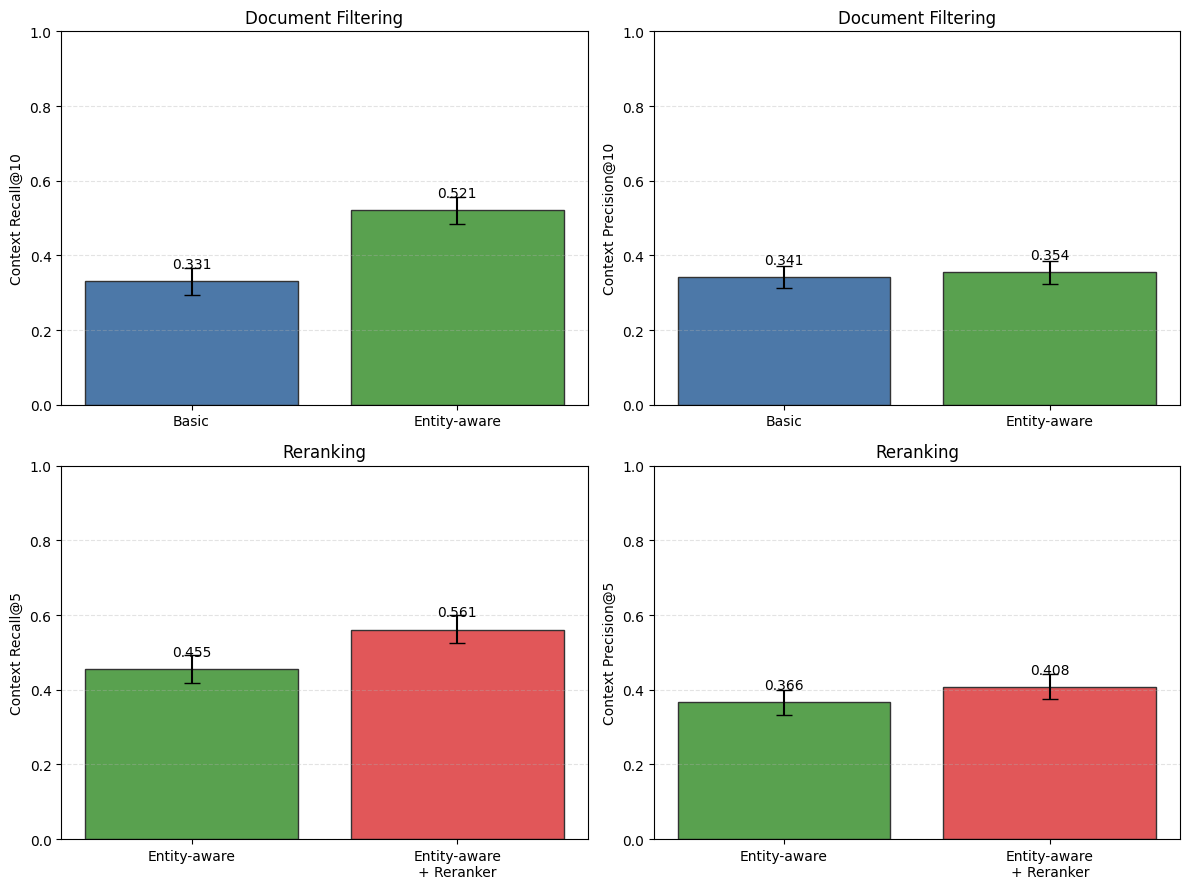

,comparison,metric,method,mean,count
0,Document Filtering,Context Recall@10,basic,0.330699,569
1,Document Filtering,Context Recall@10,entity_aware,0.520911,569
2,Document Filtering,Context Precision@10,basic,0.341265,569
3,Document Filtering,Context Precision@10,entity_aware,0.354251,569
4,Reranking,Context Recall@5,entity_aware,0.454940,569
5,Reranking,Context Recall@5,entity_aware_reranked,0.561241,569
6,Reranking,Context Precision@5,entity_aware,0.366044,569
7,Reranking,Context Precision@5,entity_aware_reranked,0.407874,569


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


recall_at10_df = context_recall_df[
    context_recall_df["method"].isin([
        "basic",
        "entity_aware",
    ])
].copy()

precision_at10_df = context_precision_at10_df.copy()

recall_at5_df = pd.concat([
    entity_aware_at5_recall_df,
    context_recall_df[
        context_recall_df["method"]
        == "entity_aware_reranked"
    ],
], ignore_index=True)

precision_at5_df = context_precision_df.copy()


panel_specs = [
    (
        recall_at10_df,
        "context_recall",
        ["basic", "entity_aware"],
        "Document Filtering",
        "Context Recall@10",
    ),
    (
        precision_at10_df,
        "context_precision",
        ["basic", "entity_aware"],
        "Document Filtering",
        "Context Precision@10",
    ),
    (
        recall_at5_df,
        "context_recall",
        ["entity_aware", "entity_aware_reranked"],
        "Reranking",
        "Context Recall@5",
    ),
    (
        precision_at5_df,
        "context_precision",
        ["entity_aware", "entity_aware_reranked"],
        "Reranking",
        "Context Precision@5",
    ),
]

label_map = {
    "basic": "Basic",
    "entity_aware": "Entity-aware",
    "entity_aware_reranked": "Entity-aware\n+ Reranker",
}

color_map = {
    "basic": "#4C78A8",
    "entity_aware": "#59A14F",
    "entity_aware_reranked": "#E15759",
}

rng = np.random.default_rng(42)
summary_rows = []

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (df, metric, methods, title, ylabel) in zip(
    axes.flat,
    panel_specs,
):
    means = []
    lower_errors = []
    upper_errors = []

    for method in methods:
        values = df.loc[
            (df["method"] == method)
            & df["error"].isna(),
            metric,
        ].to_numpy(dtype=float)

        bootstrap_means = rng.choice(
            values,
            size=(2000, len(values)),
            replace=True,
        ).mean(axis=1)

        lower, upper = np.quantile(
            bootstrap_means,
            [0.025, 0.975],
        )

        mean = values.mean()
        means.append(mean)
        lower_errors.append(mean - lower)
        upper_errors.append(upper - mean)

        summary_rows.append({
            "comparison": title,
            "metric": ylabel,
            "method": method,
            "mean": mean,
            "count": len(values),
        })

    positions = np.arange(len(methods))

    bars = ax.bar(
        positions,
        means,
        yerr=np.array([
            lower_errors,
            upper_errors,
        ]),
        capsize=6,
        color=[color_map[m] for m in methods],
        edgecolor="#333333",
    )

    ax.set_xticks(
        positions,
        [label_map[m] for m in methods],
    )
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    for bar, mean in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            mean + 0.035,
            f"{mean:.3f}",
            ha="center",
        )

plt.tight_layout()
plt.show()

evaluation_summary_df = pd.DataFrame(summary_rows)
evaluation_summary_df